En este ColabNotebook se ha implementado un modelo más clásico: <br>
Extracción de caracteríticas -> Entrenenamiento con SVM -> Predicción

# 1. Dataset

In [ ]:
import os
from google.colab import drive

# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Copiar ZIP con barra de progreso
!rsync -ah --info=progress2 "/content/drive/MyDrive/Dataset.zip" "/content/Dataset.zip"

# 3. Descomprimir ZIP
!unzip -o /content/Dataset.zip -d /content/

# 4. Detectar si existe carpeta interna /content/Dataset/Dataset
inner_path = "/content/Dataset/Dataset"
outer_path = "/content/Dataset"

if os.path.isdir(inner_path):
    print("Corrigiendo estructura interna...")

    # 4A. Copiar TODAS las imágenes desde la carpeta interna a la carpeta externa
    !find /content/Dataset/Dataset -type f -iname "*.jpg" -exec cp {} /content/Dataset/ \;

    # 4B. Mover cada imagen a su carpeta correcta
    !for img in /content/Dataset/*.jpg; do \
        orig=$(grep -R "$img" -l /content/Dataset/Dataset 2>/dev/null | head -n 1); \
        if [ ! -z "$orig" ]; then \
            letter=$(echo "$orig" | sed 's/.*Dataset\/Dataset\///' | cut -d'/' -f1); \
            mv "$img" "/content/Dataset/$letter/"; \
        fi; \
      done

    # 4C. Borrar carpeta interna sobrante
    !rm -r /content/Dataset/Dataset

# 5. Mostrar clases finales
print("Clases detectadas:")
!ls /content/Dataset

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: /content/Dataset/Z/Z (317).jpg  
  inflating: /content/Dataset/Z/Z (3170).jpg  
  inflating: /content/Dataset/Z/Z (3171).jpg  
  inflating: /content/Dataset/Z/Z (3172).jpg  
  inflating: /content/Dataset/Z/Z (3173).jpg  
  inflating: /content/Dataset/Z/Z (3174).jpg  
  inflating: /content/Dataset/Z/Z (3175).jpg  
  inflating: /content/Dataset/Z/Z (3176).jpg  
  inflating: /content/Dataset/Z/Z (3177).jpg  
  inflating: /content/Dataset/Z/Z (3178).jpg  
  inflating: /content/Dataset/Z/Z (3179).jpg  
  inflating: /content/Dataset/Z/Z (318).jpg  
  inflating: /content/Dataset/Z/Z (3180).jpg  
  inflating: /content/Dataset/Z/Z (3181).jpg  
  inflating: /content/Dataset/Z/Z (3182).jpg  
  inflating: /content/Dataset/Z/Z (3183).jpg  
  inflating: /content/Dataset/Z/Z (3184).jpg  
  inflating: /content/Dataset/Z/Z (3185).jpg  
  inflating: /content/Dataset/Z/Z (3186).jpg  
  inflating: /content/Dataset/Z/Z (3187).jpg  
 

# 1.1 Contenido del dataset

In [ ]:
import os

dataset_path = "/content/Dataset"

for carpeta in sorted(os.listdir(dataset_path)):
    ruta_carpeta = os.path.join(dataset_path, carpeta)

    if os.path.isdir(ruta_carpeta):
        num_imagenes = len([
            archivo for archivo in os.listdir(ruta_carpeta)
            if os.path.isfile(os.path.join(ruta_carpeta, archivo))
        ])

        print(f"{carpeta}: {num_imagenes} imágenes")

A: 8458 imágenes
B: 8309 imágenes
C: 8146 imágenes
D: 7629 imágenes
E: 7744 imágenes
F: 8031 imágenes
G: 7844 imágenes
H: 7906 imágenes
I: 7953 imágenes
J: 7503 imágenes
K: 7876 imágenes
L: 7939 imágenes
M: 7900 imágenes
N: 7932 imágenes
O: 8140 imágenes
P: 7601 imágenes
Q: 7954 imágenes
R: 8021 imágenes
S: 8109 imágenes
T: 8054 imágenes
U: 8023 imágenes
V: 7597 imágenes
W: 7787 imágenes
X: 8093 imágenes
Y: 8178 imágenes
Z: 7410 imágenes


In [ ]:
from PIL import Image

ruta = "/content/Dataset/A"
archivo = os.listdir(ruta)[0]

img = Image.open(os.path.join(ruta, archivo))

print(img.mode)

RGB


# 1.2 Ver imágenes del dataset

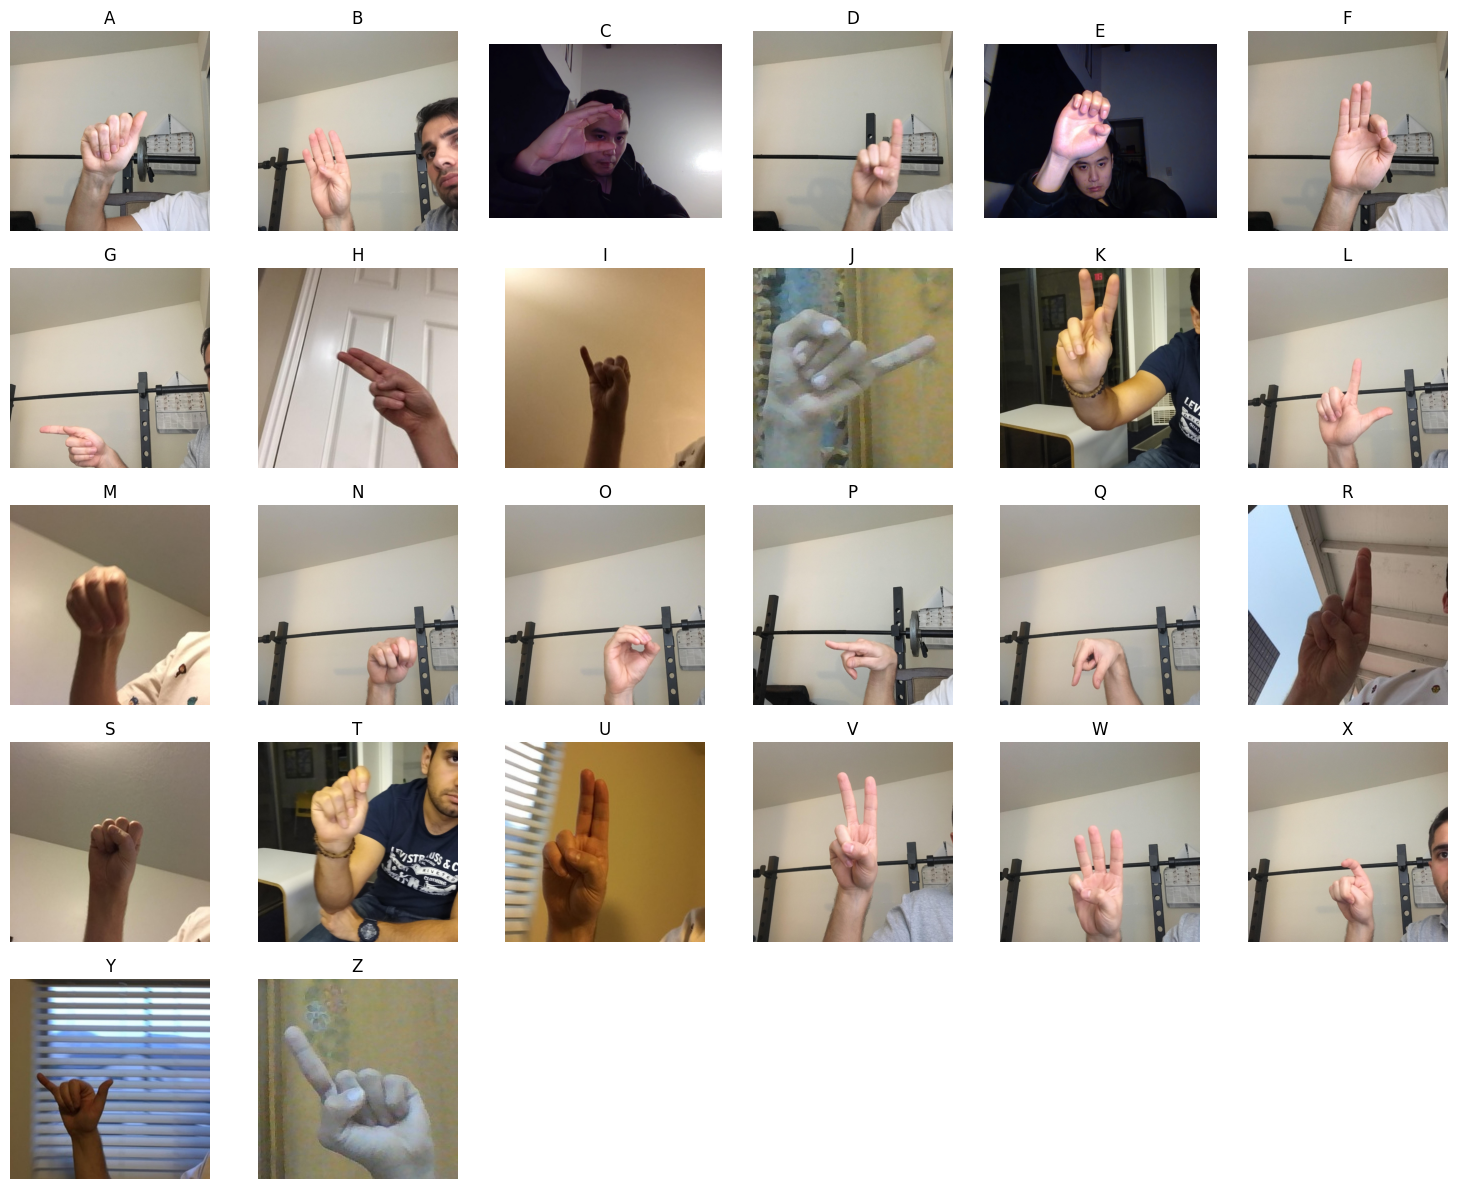

In [ ]:

import matplotlib.pyplot as plt
from PIL import Image

root = "/content/Dataset"

imagenes = []

for carpeta in sorted(os.listdir(root)):
    ruta_carpeta = os.path.join(root, carpeta)

    if os.path.isdir(ruta_carpeta):
        archivos = sorted([
            f for f in os.listdir(ruta_carpeta)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
        ])

        if archivos:
            imagenes.append((
                carpeta,
                os.path.join(ruta_carpeta, archivos[0])
            ))

# Crear cuadrícula
fig, axes = plt.subplots(5, 6, figsize=(15, 12))
axes = axes.flatten()

for ax, (letra, ruta) in zip(axes, imagenes):
    img = Image.open(ruta)
    ax.imshow(img)
    ax.set_title(letra, fontsize=12)
    ax.axis("off")

# Ocultar ejes sobrantes
for ax in axes[len(imagenes):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# 2. Extracción de Características

In [ ]:
import cv2
import random
import numpy as np

X = []
y = []

ROOT = "/content/Dataset"
MAX_POR_LETRA = 1000

for letra in sorted(os.listdir(ROOT)):

    ruta_letra = os.path.join(ROOT, letra)

    if not os.path.isdir(ruta_letra):
        continue

    archivos = [
        f for f in os.listdir(ruta_letra)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]

    # Seleccionar hasta 1000 imágenes aleatorias
    archivos = random.sample(
        archivos,
        min(MAX_POR_LETRA, len(archivos))
    )

    print(f"Cargando {len(archivos)} imágenes de la letra {letra}...")

    for archivo in archivos:

        ruta_img = os.path.join(ruta_letra, archivo)

        img = cv2.imread(ruta_img)

        if img is None:
            continue

        # Escala de grises
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Redimensionar
        img = cv2.resize(img, (128, 128))

        # Normalizar [0,1]
        img = img.astype(np.float32) / 255.0

        X.append(img)
        y.append(letra)

X = np.array(X)
y = np.array(y)

print("\n Dataset cargado")
print("X shape:", X.shape)
print("y shape:", y.shape)

Cargando 1000 imágenes de la letra A...
Cargando 1000 imágenes de la letra B...
Cargando 1000 imágenes de la letra C...
Cargando 1000 imágenes de la letra D...
Cargando 1000 imágenes de la letra E...
Cargando 1000 imágenes de la letra F...
Cargando 1000 imágenes de la letra G...
Cargando 1000 imágenes de la letra H...
Cargando 1000 imágenes de la letra I...
Cargando 1000 imágenes de la letra J...
Cargando 1000 imágenes de la letra K...
Cargando 1000 imágenes de la letra L...
Cargando 1000 imágenes de la letra M...
Cargando 1000 imágenes de la letra N...
Cargando 1000 imágenes de la letra O...
Cargando 1000 imágenes de la letra P...
Cargando 1000 imágenes de la letra Q...
Cargando 1000 imágenes de la letra R...
Cargando 1000 imágenes de la letra S...
Cargando 1000 imágenes de la letra T...
Cargando 1000 imágenes de la letra U...
Cargando 1000 imágenes de la letra V...
Cargando 1000 imágenes de la letra W...
Cargando 1000 imágenes de la letra X...
Cargando 1000 imágenes de la letra Y...


# 2.1 HOG

In [ ]:

X = []
y = []

ROOT = "/content/Dataset"
MAX_POR_LETRA = 500

for letra in sorted(os.listdir(ROOT)):

    ruta_letra = os.path.join(ROOT, letra)

    if not os.path.isdir(ruta_letra):
        continue

    archivos = [
        f for f in os.listdir(ruta_letra)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]

    # Selección aleatoria
    archivos = random.sample(
        archivos,
        min(MAX_POR_LETRA, len(archivos))
    )

    for archivo in archivos:

        ruta_img = os.path.join(ruta_letra, archivo)

        img = cv2.imread(ruta_img)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Para modelos clásicos incluso podéis bajar a 64x64
        img = cv2.resize(img, (64, 64))

        img = img.astype(np.float32) / 255.0

        X.append(img)
        y.append(letra)

X = np.array(X)
y = np.array(y)

print("Dataset cargado")
print("X shape:", X.shape)
print("y shape:", y.shape)

Dataset cargado
X shape: (13000, 64, 64)
y shape: (13000,)


## 3. Entrenar

In [ ]:
from skimage.feature import hog
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

print("Extrayendo características HOG...")

X_hog = []

for img in X:
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm="L2-Hys"
    )
    X_hog.append(features)

X_hog = np.array(X_hog)

print("Shape HOG:", X_hog.shape)

# Convertir letras a números
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_hog,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Entrenando SVM...")

svm = LinearSVC(
    random_state=42,
    max_iter=5000
)

svm.fit(X_train, y_train)

print("Evaluando...")

pred = svm.predict(X_test)

acc = accuracy_score(y_test, pred)

print(f"\n Accuracy: {acc:.4f}")

Extrayendo características HOG...
Shape HOG: (13000, 1764)
Entrenando SVM...
Evaluando...

 Accuracy: 0.7281


En este modelo estamos entrenando con SVM, el cual trabaja sobre características extraídas como HOG. HOG captura bordes, contornos, orientación del gradiente y la silueta de la mano, que permite distinguir las letras del lenguaje de signos. <br>
A diferencia de la CNN, que aprende detalles más concretos, este modelo más clásico ha sido capaz de conseguir un accuracy superior al 70%, lo cual demuestra que la mayor parte de la información discriminante se encuentra en los contornos de la mano.

In [ ]:
# GUARDAR MODELO
from google.colab import drive
import joblib

# Montar Drive
drive.mount('/content/drive')

# Ruta donde se guardará
save_path = "/content/drive/MyDrive"

# Guardar modelo SVM
joblib.dump(svm, f"{save_path}/sign_language_svm.pkl")

# Guardar LabelEncoder
joblib.dump(encoder, f"{save_path}/sign_language_label_encoder.pkl")

print("Modelo y encoder guardados en Google Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modelo y encoder guardados en Google Drive


# 4. Matriz de confusión

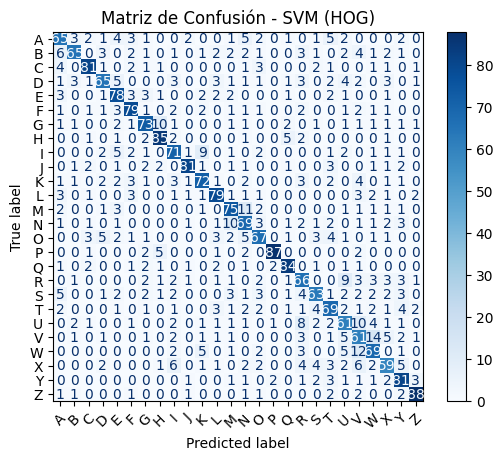


 Accuracy por letra:

A: 65.00%  (65/100)
B: 65.00%  (65/100)
C: 81.00%  (81/100)
D: 65.00%  (65/100)
E: 78.00%  (78/100)
F: 79.00%  (79/100)
G: 73.00%  (73/100)
H: 85.00%  (85/100)
I: 71.00%  (71/100)
J: 81.00%  (81/100)
K: 72.00%  (72/100)
L: 79.00%  (79/100)
M: 75.00%  (75/100)
N: 69.00%  (69/100)
O: 67.00%  (67/100)
P: 87.00%  (87/100)
Q: 84.00%  (84/100)
R: 66.00%  (66/100)
S: 63.00%  (63/100)
T: 69.00%  (69/100)
U: 61.00%  (61/100)
V: 61.00%  (61/100)
W: 69.00%  (69/100)
X: 59.00%  (59/100)
Y: 81.00%  (81/100)
Z: 88.00%  (88/100)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ─────────────────────────────────────────────
# 1. SPLIT (igual que entrenamiento, pero consistente)
# ─────────────────────────────────────────────

X_train_img, X_test_img, y_train, y_test = train_test_split(
    X,
    encoder.transform(y),   # ya codificado igual que en entrenamiento
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ─────────────────────────────────────────────
# 2. EXTRAER HOG EN TEST
# ─────────────────────────────────────────────

X_test_hog = np.array([
    hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm="L2-Hys"
    )
    for img in X_test_img
])

# ─────────────────────────────────────────────
# 3. PREDICCIÓN
# ─────────────────────────────────────────────

y_pred = svm.predict(X_test_hog)

# ─────────────────────────────────────────────
# 4. MATRIZ DE CONFUSIÓN
# ─────────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.xticks(range(len(encoder.classes_)), encoder.classes_, rotation=45)
plt.yticks(range(len(encoder.classes_)), encoder.classes_)

plt.title("Matriz de Confusión - SVM (HOG)")
plt.show()

# ─────────────────────────────────────────────
# 5. ACCURACY POR LETRA
# ─────────────────────────────────────────────

print("\n Accuracy por letra:\n")

for i, name in enumerate(encoder.classes_):

    idx = (y_test == i)

    total = np.sum(idx)
    correct = np.sum(y_pred[idx] == i)

    acc = (correct / total * 100) if total > 0 else 0

    print(f"{name}: {acc:.2f}%  ({correct}/{total})")

A diferencia de la matriz de confusión de la CNN que se extrajo con un dataset externo, en este caso la matriz de confusión es con el mismo dataset de entrenamiento, que es más pequeño.<br>
Podemos ver que no se consigue un 100% como en el caso anterior, pero no hay confusiones fuertes entre letras.

# 5. Visualizar HOG

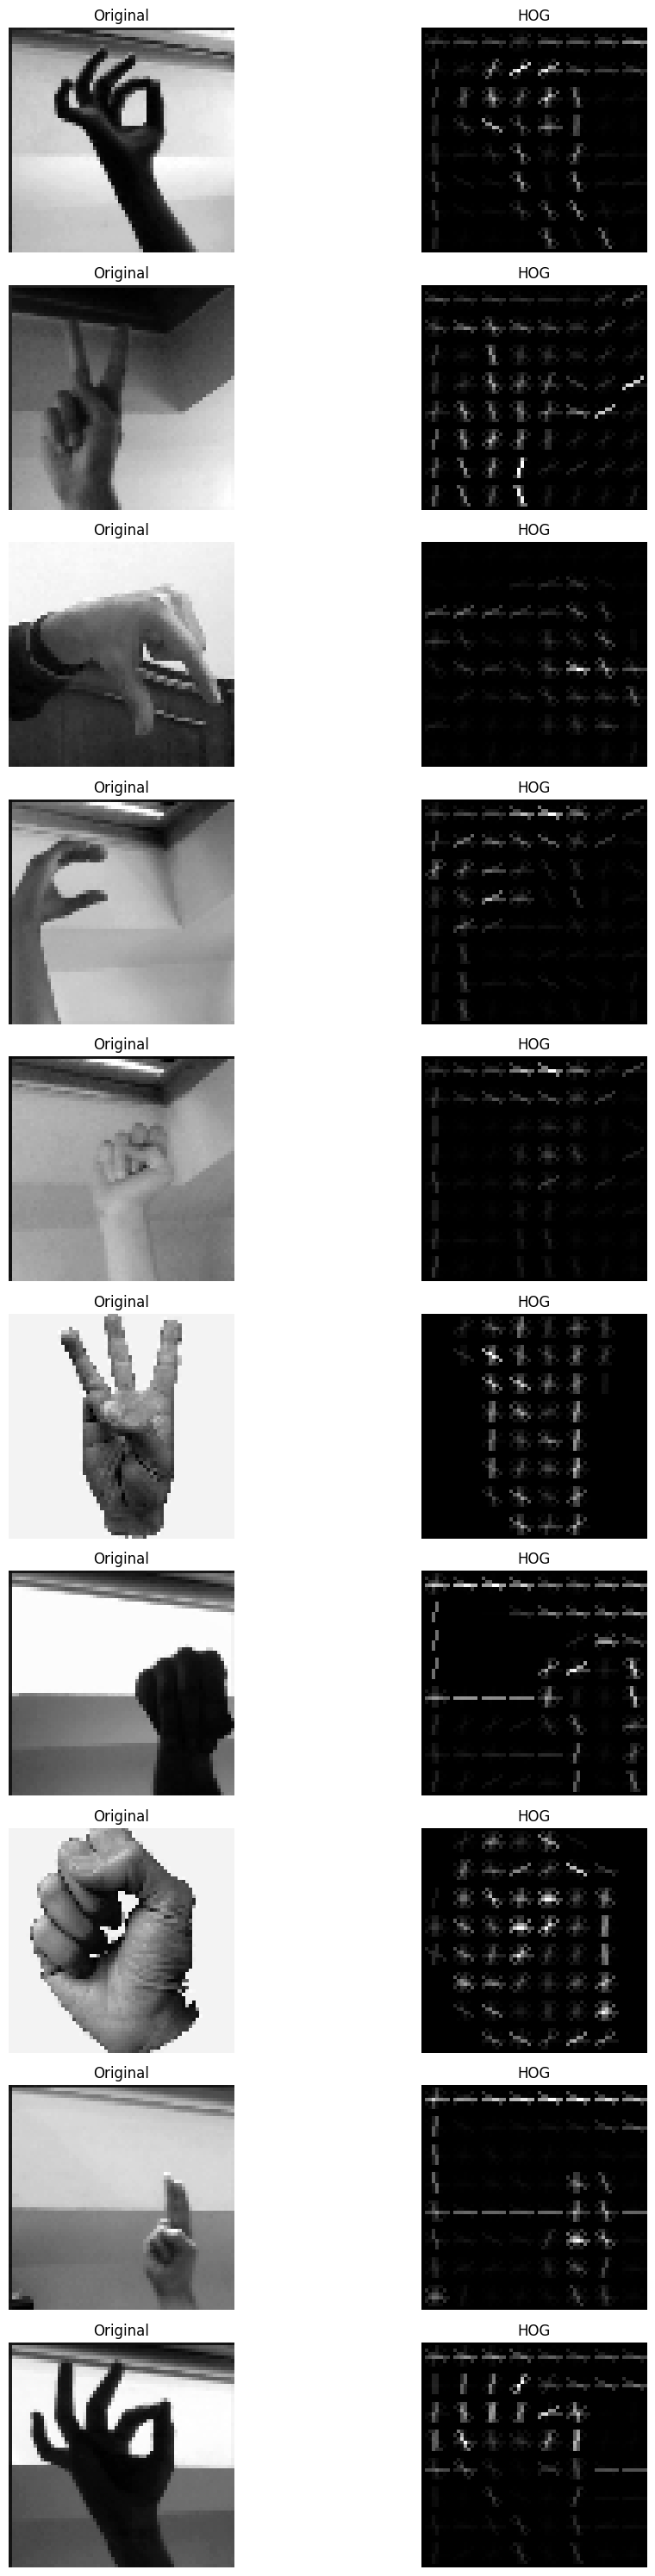

In [ ]:
import matplotlib.pyplot as plt
from skimage.feature import hog

n = 10

plt.figure(figsize=(12, 3*n))

for i in range(n):

    img = X_test_img[i]

    _, hog_image = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm="L2-Hys",
        visualize=True
    )

    # Imagen original
    plt.subplot(n, 2, 2*i + 1)
    plt.imshow(img, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # HOG
    plt.subplot(n, 2, 2*i + 2)
    plt.imshow(hog_image, cmap="gray")
    plt.title("HOG")
    plt.axis("off")

plt.tight_layout()
plt.show()

Aquí se ha visualizado el HOG de algunas imágenes del dataset. Podemos apreciar que en su mayoría capta bien el contorno de la mano cuando no hay un fondo muy ruidoso. Sin embargo, cuando el fondo tiene estructuras geométricas, dependiendo del signo, puede no captar bien la forma de la mano y ser más fuerte los gradientes del fondo.

# 6. Regiones importantes

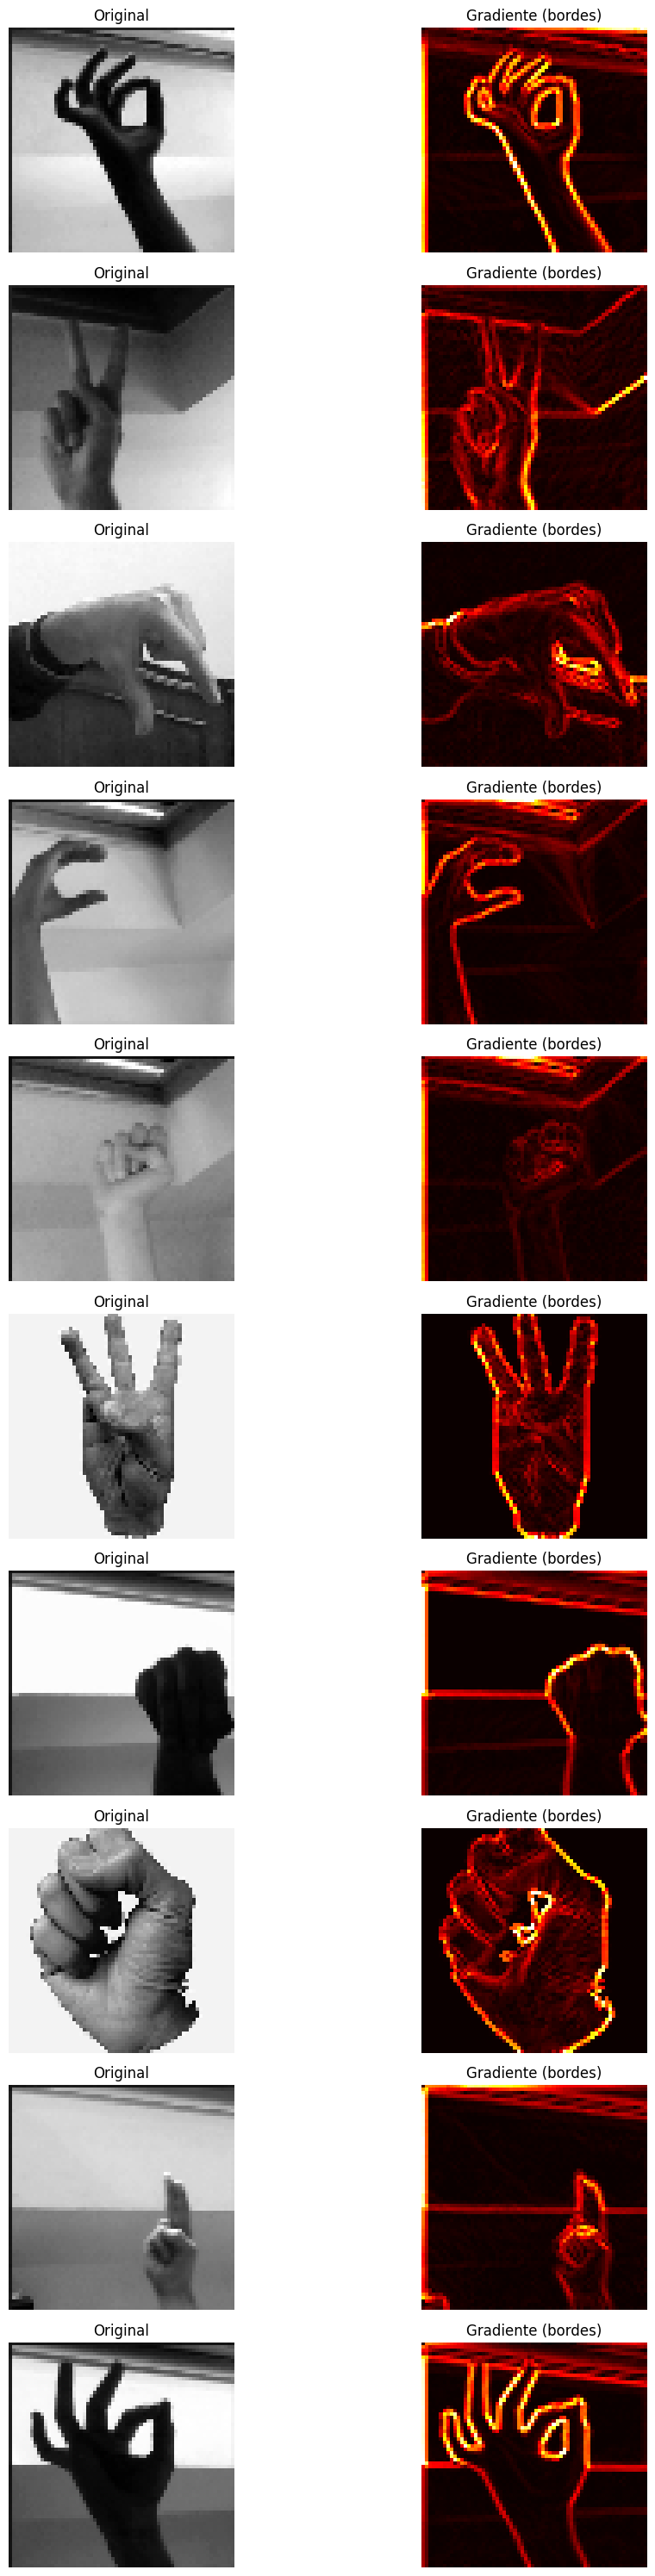

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n = 10

plt.figure(figsize=(12, 3*n))

for i in range(n):

    img = X_test_img[i]

    gx = np.abs(np.gradient(img, axis=1))
    gy = np.abs(np.gradient(img, axis=0))

    grad = gx + gy

    plt.subplot(n, 2, 2*i + 1)
    plt.imshow(img, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(n, 2, 2*i + 2)
    plt.imshow(grad, cmap="hot")
    plt.title("Gradiente (bordes)")
    plt.axis("off")

plt.tight_layout()
plt.show()

Con estas imágenes confirmamos lo dicho anteriormente: dependiendo del fondo puede que tome más importancia éste que la mano en sí, causando dificultades en el aprendizaje correcto del signo adecuado.

# CONLCUSIONES
Se ha desarrollado un sistema completo de reconocimiento de lenguaje de signos americano (ASL) mediante dos tipos de aprendizaje automático y se ha integrado en una aplicación interactiva funcional. Por otro lado, se ha comparado un enfoque clásico de visión artificial basado en descriptores HOG y clasificación mediante SVM con un enfoque deep-learnig basado en redes convolucionales (CNN).<br>
<br>
El modelo HOG+SVM ha alcanzado una precisión del 72.8%, emostrando que los gradientes y contornos contienen información relevante para la identificación de signos. Sin embargo, la CNN obtuvo una precisión del 86,0 %, superando al enfoque clásico en un 13,2%.Estos resultados sugieren que las representaciones aprendidas automáticamente por la CNN permiten capturar patrones espaciales más complejos y discriminativos que los descriptores manuales, especialmente en signos con formas similares.<br>
El uso de Transfer Learning con MobileNetV2 preentrenado en ImageNet, ha sido clave para alcanzar una precisión competitiva con un dataset de tamaño moderado y sin necesidad de entrenar una arquitectura profunda desde cero.
<br><br>
En cuanto a la aplicación desarrollada, se ha enfocado como una app de aprendizaje y comunicación. Dispone de dos modos: uno de aprendizaje guiado y otro de competición por tiempo. Además, hay un tercer modo que permite la comunicación en tiempo real mediante lengua de signos.<br>




